# Reactive Signal Edge — Finviz Top Gainers → Price Continuation

## Pregunta central
Cuando un ticker aparece en **Finviz Top Gainers** con un determinado `change_pct` en un snapshot intradiario,
¿continúa subiendo en los siguientes **15 / 30 / 60 / 120 minutos**?

## Fuentes de datos
| Tabla | Rol | Cobertura |
|---|---|---|
| `snapshots` (prod DB) | **Señal de entrada** — aparición en Top Gainers | Mar 24 – Apr 17, ~5-15 min interval |
| `bars` (burst_intraday_cache.db) | **Outcome** — precio real 1-min post-señal | Mar 25 – Apr 16, 92 tickers |
| `hype_metrics` (prod DB) | **Enriquecimiento** — rel_volume, delta_5m | Apr 14-17 |

## Sesgos conocidos (ver celda 3b)
- **Dependencia**: múltiples snapshots del mismo ticker-día no son independientes → usar `df_valid_indep`
- **Survivorship**: burst cache tiene ~14 tickers; backfill amplía a 177
- **Slippage**: ~0.5-2% en small caps, no modelado en forward returns
- **Régimen**: semana 16 (crash abril) con WR diferente al resto

## Estructura del directorio
```
reactive_signal/
  reactive_signal_edge.ipynb
  backfill_snapshot_bars.py    ← descarga barras 1-min faltantes de IBKR
  helpers/
    data_loader.py
    signal_builder.py          ← one_per_ticker_day=True para tests estadísticos
    forward_returns.py
  figures/
```

In [1]:
import sys
from pathlib import Path

NB_DIR = Path('.')
sys.path.insert(0, str(NB_DIR))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from helpers import (
    load_snapshots, load_intraday_bars, load_hype_metrics,
    build_signal_events,
    compute_forward_returns, BarsIndex,
)
from helpers.forward_returns import edge_summary

FIGURES_DIR = NB_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

MIN_CHG_PCT = 15.0
HORIZONS    = [15, 30, 60, 120]

print('Imports OK')

Imports OK


## 1. Carga de datos

In [2]:
snaps_raw = load_snapshots(min_change_pct=0.0)
bars_df   = load_intraday_bars()
hype_df   = load_hype_metrics()

print(f'Snapshots  : {len(snaps_raw):,} rows | {snaps_raw["ticker"].nunique()} tickers | {snaps_raw["date"].nunique()} días')
print(f'Barras 1min: {len(bars_df):,} rows  | {bars_df["ticker"].nunique()} tickers | {bars_df["date"].nunique()} días')
print(f'Hype       : {len(hype_df):,} rows (enrichment Apr 14+)')
print()
print('Snapshots range:', snaps_raw['date'].min(), '->', snaps_raw['date'].max())
print('Barras range   :', bars_df['date'].min(), '->', bars_df['date'].max())

Snapshots  : 4,070 rows | 177 tickers | 17 días
Barras 1min: 41,620 rows  | 92 tickers | 15 días
Hype       : 26,546 rows (enrichment Apr 14+)

Snapshots range: 2026-03-24 -> 2026-04-17
Barras range   : 2026-03-25 -> 2026-04-16


## 2. Construcción de eventos de señal

Para cada snapshot con `change_pct >= MIN_CHG_PCT`:
- `appearance_n`: n-ésima aparición del ticker ese día (1 = primera)
- `session`: bucket horario (`9:30-10:00`, `10:00-11:00`, ...)
- `momentum_dir`: `first_appearance` | `accelerating` | `flat` | `decelerating`

In [3]:
events = build_signal_events(snaps_raw, min_change_pct=MIN_CHG_PCT)

print(f'Eventos (change_pct >= {MIN_CHG_PCT}%): {len(events):,}')
print(f'Tickers: {events["ticker"].nunique()} | Días: {events["date"].nunique()}')
print()
print('Por sesión:')
print(events['session'].value_counts().sort_index())
print()
print('Por n° de aparición (primeras 10):')
print(events['appearance_n'].value_counts().sort_index().head(10))

Eventos (change_pct >= 15.0%): 4,070
Tickers: 177 | Días: 17

Por sesión:
session
10:00-11:00     632
11:00-13:00    1276
13:00-15:00    1360
15:00-16:00     650
9:30-10:00      152
Name: count, dtype: int64

Por n° de aparición (primeras 10):
appearance_n
1     237
2     200
3     185
4     173
5     164
6     156
7     150
8     139
9     131
10    121
Name: count, dtype: int64


## 3. Forward returns — join con barras 1-min

- **Entrada**: open del primer bar estrictamente después del snapshot
- **Salida**: close del bar más cercano a entry + horizonte
- **MFE/MAE**: max high/low dentro de la ventana

In [4]:
bars_index = BarsIndex(bars_df)

print('Calculando forward returns...')
df = compute_forward_returns(events, bars_index, horizons=HORIZONS)
df_valid = df.dropna(subset=['ret_15m']).copy()

# Dataset con independencia: un evento por (ticker, date) — para tests estadísticos
events_indep = build_signal_events(snaps_raw, min_change_pct=MIN_CHG_PCT, one_per_ticker_day=True)
df_indep     = compute_forward_returns(events_indep, bars_index, horizons=HORIZONS)
df_valid_indep = df_indep.dropna(subset=['ret_15m']).copy()

print(f'Eventos totales            : {len(df):,}')
print(f'Con barras (todos)         : {len(df_valid):,}  ({df_valid["ticker"].nunique()} tickers únicos)')
print(f'Con barras (1 por ticker-day): {len(df_valid_indep):,}  ← para tests estadísticos')
print(f'Sin match (no en cache)    : {len(df) - len(df_valid):,}')
print(f'Cobertura: {df_valid["date"].nunique()} días | {df_valid["ticker"].nunique()} tickers')

Calculando forward returns...


Eventos totales            : 4,070
Con barras (todos)         : 146  (14 tickers únicos)
Con barras (1 por ticker-day): 14  ← para tests estadísticos
Sin match (no en cache)    : 3,924
Cobertura: 8 días | 14 tickers


## 3b. Auditoría de sesgos — leer antes de interpretar resultados

Diagnóstico sistemático de los principales riesgos del análisis.

In [5]:
from scipy import stats
import numpy as np

print('=' * 65)
print('AUDITORIA DE SESGOS')
print('=' * 65)

# 1. Independencia
print('--- 1. Independencia de observaciones ---')
tc = df_valid.groupby('ticker').size().sort_values(ascending=False)
print(f'  Obs totales: {len(df_valid)}  |  Tickers únicos: {df_valid["ticker"].nunique()}')
print(f'  Top 5 tickers por n obs: {dict(tc.head(5))}')
print(f'  RIESGO: observaciones NO independientes (mismo ticker múltiples veces).')
print(f'  FIX: df_valid_indep tiene 1 obs por ticker-day (n={len(df_valid_indep)}).\n')

# 2. Survivorship bias
n_snap_tickers = events['ticker'].nunique()
n_matched_tickers = df_valid['ticker'].nunique()
print('--- 2. Survivorship bias ---')
print(f'  Tickers en señales: {n_snap_tickers}  |  Con barras: {n_matched_tickers}  |  Sin barras: {n_snap_tickers - n_matched_tickers}')
print(f'  Los tickers sin barras fueron descargados en contexto de PBT1 — podrían ser mejores picks.')
print(f'  FIX: backfill cubre los faltantes.\n')

# 3. Régimen de mercado
print('--- 3. Régimen de mercado ---')
df_valid['week'] = pd.to_datetime(df_valid['date']).dt.isocalendar().week.astype(int)
wk = df_valid.groupby('week')['ret_30m'].agg(n='count', wr=lambda s: (s>0).mean(), avg=lambda s: s.mean()*100)
print(wk.to_string(float_format='{:.3f}'.format))
print(f'  RIESGO: semana 16 (crash abril) tiene WR diferente al resto.\n')

# 4. Significancia con dataset independiente
print('--- 4. Significancia estadística (dataset independiente, 1 obs por ticker-day) ---')
for h in HORIZONS[:3]:
    s = df_valid_indep[f'ret_{h}m'].dropna()
    if len(s) < 5: print(f'  T+{h}m: n insuficiente ({len(s)})'); continue
    t, p = stats.ttest_1samp(s, 0)
    sig = 'SIGNIFICATIVO' if p < 0.05 else 'no significativo'
    print(f'  T+{h}m: n={len(s)}  mean={s.mean()*100:.2f}%  t={t:.2f}  p={p:.4f}  → {sig}')

# 5. Bootstrap CI con dataset independiente
print()
print('--- 5. Bootstrap CI 95% (dataset independiente, T+30m) ---')
s30 = df_valid_indep['ret_30m'].dropna().values
if len(s30) >= 5:
    np.random.seed(42)
    boot_wr, boot_pf = [], []
    for _ in range(5000):
        smp = np.random.choice(s30, size=len(s30), replace=True)
        boot_wr.append((smp > 0).mean())
        w = smp[smp > 0]; l = smp[smp < 0]
        boot_pf.append(w.sum() / abs(l.sum()) if len(l) > 0 else 2.0)
    wr_obs = (s30 > 0).mean()
    pf_obs = s30[s30>0].sum() / abs(s30[s30<0].sum())
    print(f'  WR: {wr_obs:.1%}  CI95=[{np.percentile(boot_wr,2.5):.1%}, {np.percentile(boot_wr,97.5):.1%}]')
    print(f'  PF: {pf_obs:.2f}x  CI95=[{np.percentile(boot_pf,2.5):.2f}x, {np.percentile(boot_pf,97.5):.2f}x]')
    print(f'  Si CI del PF incluye 1.0x → edge NO demostrado con estos datos.')

# 6. Slippage
print()
print('--- 6. Slippage estimado ---')
br = bars_df[bars_df['open'] > 0].copy()
br['rng'] = (br['high'] - br['low']) / br['open'] * 100
print(f'  Rango bar 1-min (proxy): median={br["rng"].median():.2f}%  p75={br["rng"].quantile(.75):.2f}%  p90={br["rng"].quantile(.9):.2f}%')
print(f'  Slippage realista small-caps: 0.5-2%. Descontar del avg_win al evaluar viabilidad.')


AUDITORIA DE SESGOS
--- 1. Independencia de observaciones ---
  Obs totales: 146  |  Tickers únicos: 14
  Top 5 tickers por n obs: {'HUBC': np.int64(38), 'ZNTL': np.int64(33), 'AIXI': np.int64(25), 'MKDW': np.int64(17), 'XNDU': np.int64(16)}
  RIESGO: observaciones NO independientes (mismo ticker múltiples veces).
  FIX: df_valid_indep tiene 1 obs por ticker-day (n=14).

--- 2. Survivorship bias ---
  Tickers en señales: 177  |  Con barras: 14  |  Sin barras: 163
  Los tickers sin barras fueron descargados en contexto de PBT1 — podrían ser mejores picks.
  FIX: backfill cubre los faltantes.

--- 3. Régimen de mercado ---
       n    wr    avg
week                 
13    22 0.636  0.686
15    68 0.603  3.520
16    56 0.500 -0.201
  RIESGO: semana 16 (crash abril) tiene WR diferente al resto.

--- 4. Significancia estadística (dataset independiente, 1 obs por ticker-day) ---
  T+15m: n=14  mean=-0.74%  t=-0.38  p=0.7121  → no significativo
  T+30m: n=14  mean=-0.69%  t=-0.23  p=0.8207  →

## 4. Edge global por horizonte

Edge global — dataset INDEPENDIENTE + slippage 0.5% (n=14)
horizonte  n    wr  profit_factor  avg_ret_pct  avg_win_pct  avg_loss_pct  median_ret_pct
    T+15m 14 0.286          0.631       -1.243        7.425        -4.710          -3.091
    T+30m 14 0.429          0.732       -1.187        7.563        -7.749          -1.682
    T+60m 14 0.429          1.072        0.482       16.660       -11.651          -0.603
   T+120m 14 0.429          0.961       -0.300       17.477       -13.633          -1.614

Exploratorio — todos los eventos, sin slippage (n=146)
horizonte   n    wr  profit_factor  avg_ret_pct  avg_win_pct  avg_loss_pct  median_ret_pct
    T+15m 146 0.568          1.326        0.831        5.944        -6.100           0.707
    T+30m 146 0.568          1.576        1.666        8.016        -6.809           1.034
    T+60m 146 0.623          2.203        3.459       10.161        -7.772           2.025
   T+120m 146 0.726          3.082        6.202       12.645       -11.

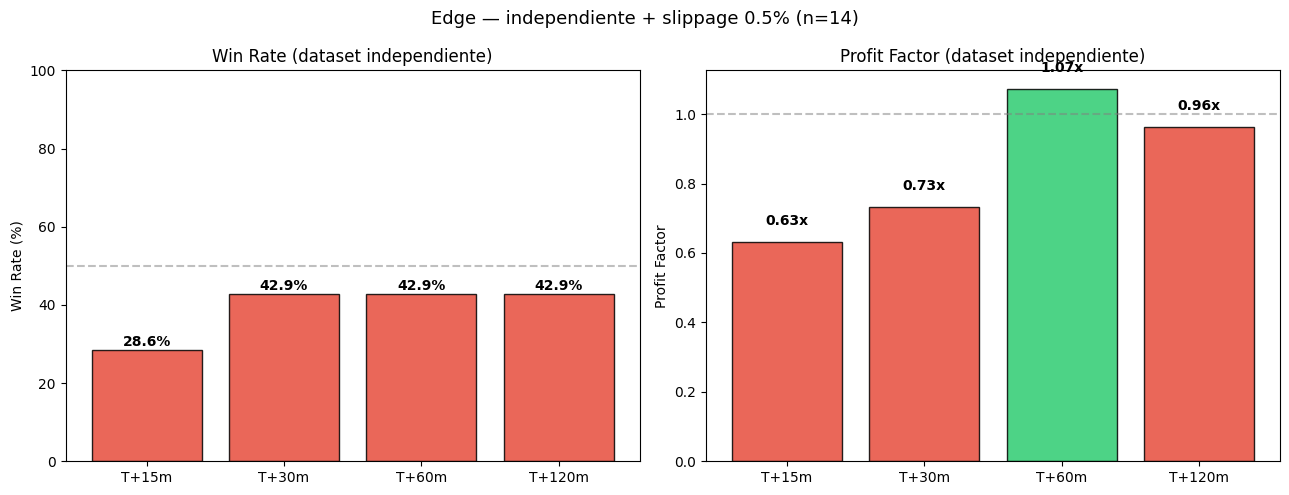

In [6]:
# Dos vistas:
#   df_valid       — todos los eventos (exploratorio, obs correlacionadas)
#   df_valid_indep — 1 obs por ticker-day (para tests estadísticos válidos)

SLIPPAGE_PCT = 0.005   # 0.5% — estimación conservadora para small caps volátiles

for d in [df_valid, df_valid_indep]:
    for h in HORIZONS:
        d[f'ret_net_{h}m'] = d[f'ret_{h}m'] - SLIPPAGE_PCT

# edge_summary con col_prefix='ret_net' — sin renombrar columnas
summary_indep = edge_summary(df_valid_indep, HORIZONS, col_prefix='ret_net')
summary_all   = edge_summary(df_valid,       HORIZONS, col_prefix='ret')

print(f'Edge global — dataset INDEPENDIENTE + slippage {SLIPPAGE_PCT*100:.1f}% (n={len(df_valid_indep)})')
print(summary_indep.to_string(index=False, float_format='{:.3f}'.format))
print()
print(f'Exploratorio — todos los eventos, sin slippage (n={len(df_valid)})')
print(summary_all.to_string(index=False, float_format='{:.3f}'.format))
print()
print('Usar summary_indep para conclusiones. summary_all solo para exploración.')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Edge — independiente + slippage {SLIPPAGE_PCT*100:.1f}% (n={len(df_valid_indep)})', fontsize=13)

ax = axes[0]
colors = ['#2ecc71' if float(wr) >= 0.5 else '#e74c3c' for wr in summary_indep['wr']]
b = ax.bar(summary_indep['horizonte'], summary_indep['wr'].astype(float) * 100, color=colors, alpha=0.85, edgecolor='black')
ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Win Rate (%)')
ax.set_title('Win Rate (dataset independiente)')
ax.set_ylim(0, 100)
for bar, wr in zip(b, summary_indep['wr'].astype(float)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{wr:.1%}', ha='center', fontsize=10, fontweight='bold')

ax = axes[1]
pf_vals = summary_indep['profit_factor'].astype(float).clip(upper=5)
colors_pf = ['#2ecc71' if pf >= 1 else '#e74c3c' for pf in pf_vals]
b2 = ax.bar(summary_indep['horizonte'], pf_vals, color=colors_pf, alpha=0.85, edgecolor='black')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Profit Factor')
ax.set_title('Profit Factor (dataset independiente)')
for bar, pf in zip(b2, summary_indep['profit_factor'].astype(float)):
    ax.text(bar.get_x() + bar.get_width()/2, min(bar.get_height(), 5) + 0.05,
            f'{pf:.2f}x', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'edge_global.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Segmentación por sesión (hora del día)

Régimen normal (sem ≠16): n=11 | Crash (sem 16): n=3



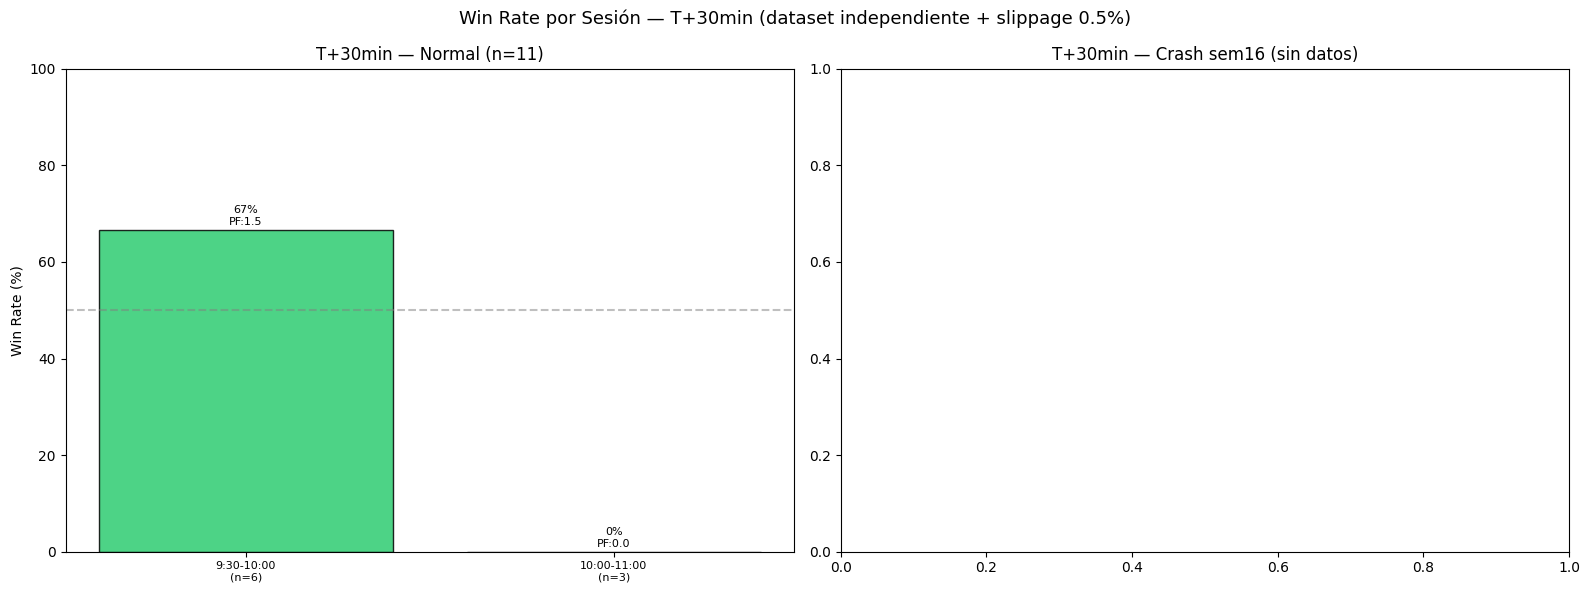

In [7]:
SESSION_ORDER = ['9:30-10:00', '10:00-11:00', '11:00-13:00', '13:00-15:00', '15:00-16:00']

# Separar régimen normal vs crash (semana 16 = Apr 14-17)
df_valid_indep['week'] = pd.to_datetime(df_valid_indep['date']).dt.isocalendar().week.astype(int)
df_normal = df_valid_indep[df_valid_indep['week'] != 16]
df_crash  = df_valid_indep[df_valid_indep['week'] == 16]
print(f'Régimen normal (sem ≠16): n={len(df_normal)} | Crash (sem 16): n={len(df_crash)}')
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Win Rate por Sesión — T+30min (dataset independiente + slippage 0.5%)', fontsize=13)

for ax, (label, dset) in zip(axes, [('Normal', df_normal), ('Crash sem16', df_crash)]):
    col = 'ret_net_30m'
    rows = []
    for sess in SESSION_ORDER:
        s = dset[dset['session'] == sess][col].dropna()
        if len(s) < 3:
            continue
        pf = s[s > 0].sum() / abs(s[s < 0].sum()) if (s < 0).any() else 2.0
        rows.append({'session': sess, 'n': len(s), 'wr': (s > 0).mean(), 'pf': pf})
    if not rows:
        ax.set_title(f'T+30min — {label} (sin datos)')
        continue
    df_s = pd.DataFrame(rows)
    colors = ['#2ecc71' if wr >= 0.5 else '#e74c3c' for wr in df_s['wr']]
    b = ax.bar(range(len(df_s)), df_s['wr'] * 100, color=colors, alpha=0.85, edgecolor='black')
    ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
    ax.set_xticks(range(len(df_s)))
    ax.set_xticklabels([f"{r['session']}\n(n={r['n']})" for _, r in df_s.iterrows()], fontsize=8)
    ax.set_ylabel('Win Rate (%)')
    ax.set_title(f'T+30min — {label} (n={len(dset)})')
    ax.set_ylim(0, 100)
    for bar, row in zip(b, df_s.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{row.wr:.0%}\nPF:{row.pf:.1f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'edge_by_session.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Segmentación por change_pct al momento de la señal

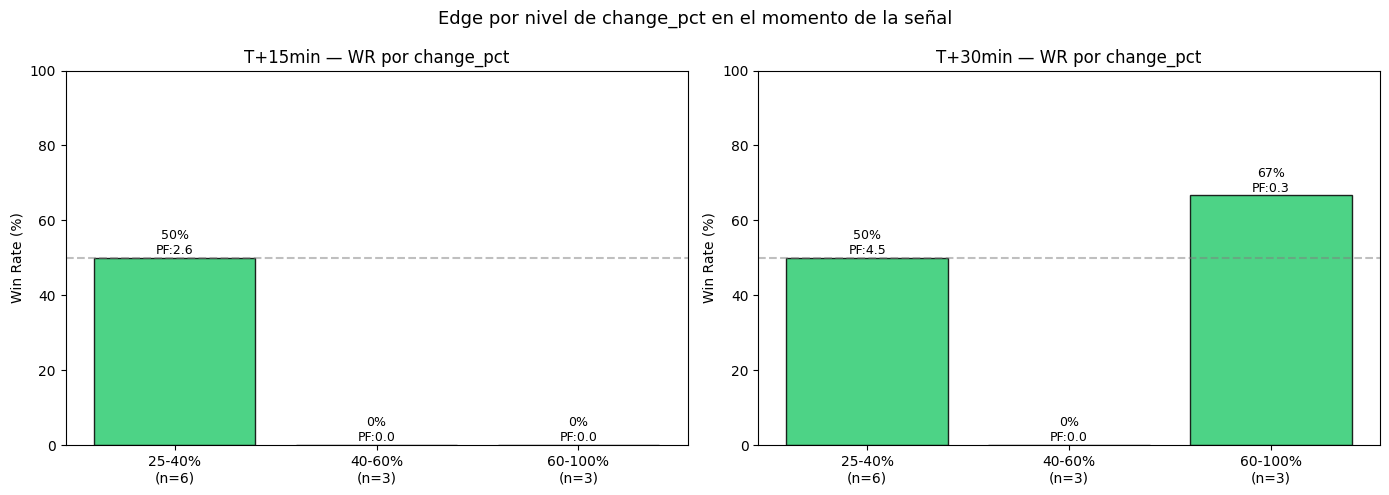

In [8]:
df_valid_indep['chg_bucket'] = pd.cut(
    df_valid_indep['change_pct'],
    bins=[15, 25, 40, 60, 100, 500],
    labels=['15-25%', '25-40%', '40-60%', '60-100%', '100%+']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Edge por nivel de change_pct en el momento de la señal', fontsize=13)

for ax, h in zip(axes, [15, 30]):
    col = f'ret_net_{h}m'
    rows = []
    for bucket in ['15-25%', '25-40%', '40-60%', '60-100%', '100%+']:
        s = df_valid_indep[df_valid_indep['chg_bucket'] == bucket][col].dropna()
        if len(s) < 3:
            continue
        pf = s[s > 0].sum() / abs(s[s < 0].sum()) if (s < 0).any() else 2.0
        rows.append({'bucket': bucket, 'n': len(s), 'wr': (s > 0).mean(), 'avg_ret': s.mean() * 100, 'pf': pf})
    df_c = pd.DataFrame(rows)
    if len(df_c) == 0:
        continue
    colors = ['#2ecc71' if wr >= 0.5 else '#e74c3c' for wr in df_c['wr']]
    b = ax.bar(range(len(df_c)), df_c['wr'] * 100, color=colors, alpha=0.85, edgecolor='black')
    ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
    ax.set_xticks(range(len(df_c)))
    ax.set_xticklabels([f"{r['bucket']}\n(n={r['n']})" for _, r in df_c.iterrows()])
    ax.set_ylabel('Win Rate (%)')
    ax.set_title(f'T+{h}min — WR por change_pct')
    ax.set_ylim(0, 100)
    for bar, row in zip(b, df_c.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{row.wr:.0%}\nPF:{row.pf:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'edge_by_changepct.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Primera aparición vs apariciones posteriores

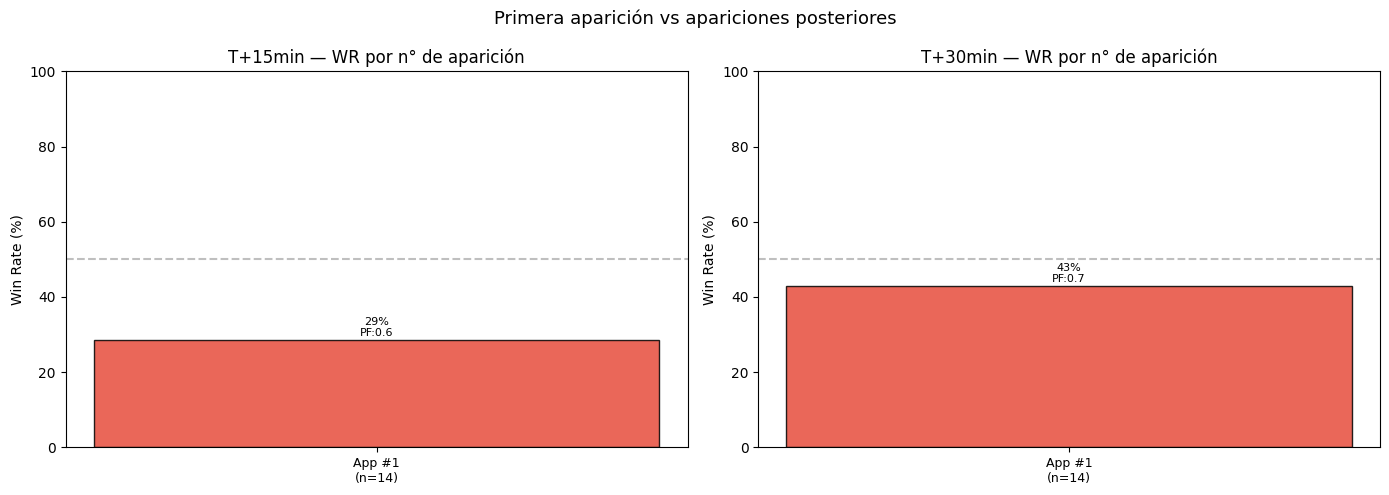

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Primera aparición vs apariciones posteriores', fontsize=13)

for ax, h in zip(axes, [15, 30]):
    col = f'ret_net_{h}m'
    rows = []
    for n in range(1, 8):
        s = df_valid_indep[df_valid_indep['appearance_n'] == n][col].dropna()
        if len(s) < 3:
            continue
        pf = s[s > 0].sum() / abs(s[s < 0].sum()) if (s < 0).any() else 2.0
        rows.append({'label': f'#{n}', 'n': len(s), 'wr': (s > 0).mean(), 'pf': pf})
    s = df_valid_indep[df_valid_indep['appearance_n'] >= 8][col].dropna()
    if len(s) >= 3:
        pf = s[s > 0].sum() / abs(s[s < 0].sum()) if (s < 0).any() else 2.0
        rows.append({'label': '#8+', 'n': len(s), 'wr': (s > 0).mean(), 'pf': pf})
    df_a = pd.DataFrame(rows)
    if len(df_a) == 0:
        continue
    colors = ['#2ecc71' if wr >= 0.5 else '#e74c3c' for wr in df_a['wr']]
    b = ax.bar(range(len(df_a)), df_a['wr'] * 100, color=colors, alpha=0.85, edgecolor='black')
    ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
    ax.set_xticks(range(len(df_a)))
    ax.set_xticklabels([f"App {r['label']}\n(n={r['n']})" for _, r in df_a.iterrows()], fontsize=9)
    ax.set_ylabel('Win Rate (%)')
    ax.set_title(f'T+{h}min — WR por n° de aparición')
    ax.set_ylim(0, 100)
    for bar, row in zip(b, df_a.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{row.wr:.0%}\nPF:{row.pf:.1f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'edge_by_appearance.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Momentum del snapshot: change_pct acelerando vs frenando

`momentum_dir` compara el `change_pct` actual con el snapshot anterior del mismo ticker-día:
- `accelerating`: change_pct sube >0.5pp entre snapshots
- `decelerating`: baja >0.5pp
- `flat`: dentro del rango ±0.5pp

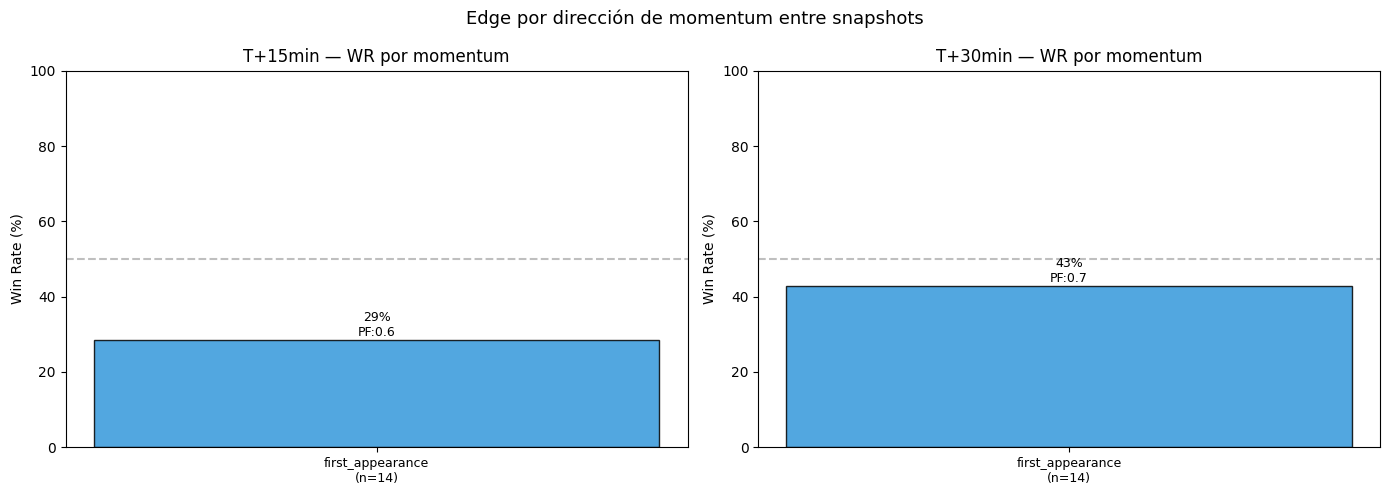

In [10]:
MOM_ORDER  = ['first_appearance', 'accelerating', 'flat', 'decelerating']
MOM_COLORS = {'first_appearance': '#3498db', 'accelerating': '#2ecc71',
               'flat': '#f39c12', 'decelerating': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Edge por dirección de momentum entre snapshots', fontsize=13)

for ax, h in zip(axes, [15, 30]):
    col = f'ret_net_{h}m'
    rows = []
    for m in MOM_ORDER:
        s = df_valid_indep[df_valid_indep['momentum_dir'] == m][col].dropna()
        if len(s) < 3:
            continue
        pf = s[s > 0].sum() / abs(s[s < 0].sum()) if (s < 0).any() else 2.0
        rows.append({'dir': m, 'n': len(s), 'wr': (s > 0).mean(), 'pf': pf})
    df_m = pd.DataFrame(rows)
    if len(df_m) == 0:
        continue
    colors = [MOM_COLORS.get(d, '#999') for d in df_m['dir']]
    b = ax.bar(range(len(df_m)), df_m['wr'] * 100, color=colors, alpha=0.85, edgecolor='black')
    ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
    ax.set_xticks(range(len(df_m)))
    ax.set_xticklabels([f"{r['dir']}\n(n={r['n']})" for _, r in df_m.iterrows()], fontsize=9)
    ax.set_ylabel('Win Rate (%)')
    ax.set_title(f'T+{h}min — WR por momentum')
    ax.set_ylim(0, 100)
    for bar, row in zip(b, df_m.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{row.wr:.0%}\nPF:{row.pf:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'edge_momentum_dir.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Distribución de retornos — long tail

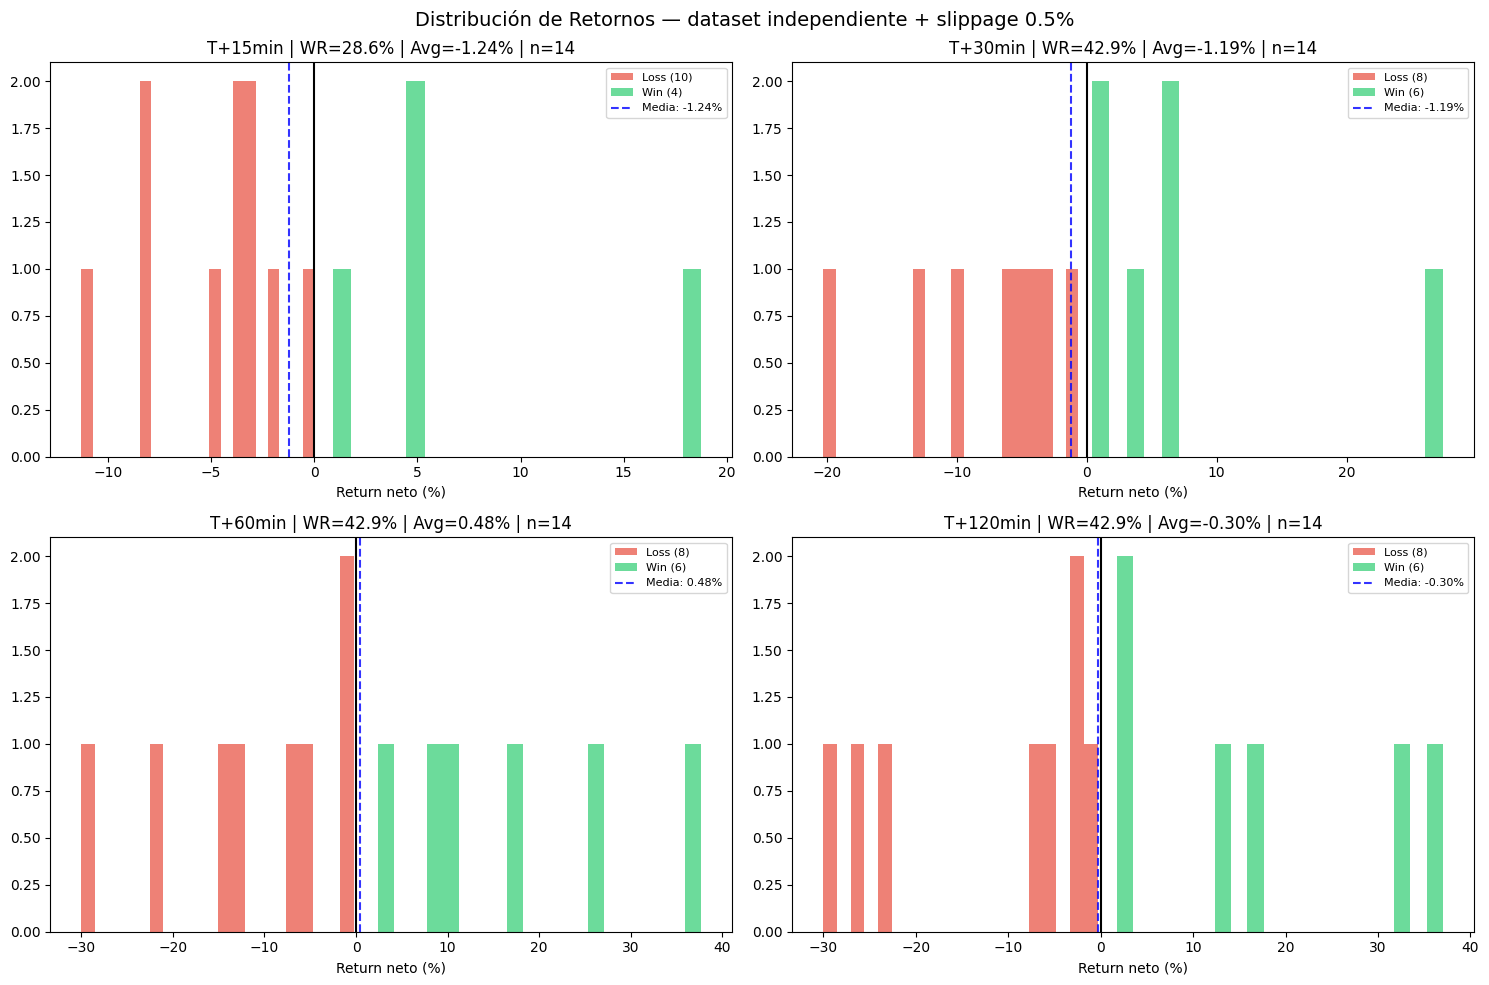

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribución de Retornos — dataset independiente + slippage 0.5%', fontsize=14)

for idx, h in enumerate(HORIZONS[:4]):
    ax  = axes[idx // 2][idx % 2]
    s   = df_valid_indep[f'ret_net_{h}m'].dropna() * 100
    s_c = s.clip(-30, 50)
    n_pos = (s > 0).sum()
    n_neg = (s < 0).sum()
    if n_pos + n_neg == 0:
        continue
    ax.hist(s_c[s_c < 0],  bins=20, color='#e74c3c', alpha=0.7, label=f'Loss ({n_neg})')
    ax.hist(s_c[s_c >= 0], bins=20, color='#2ecc71', alpha=0.7, label=f'Win ({n_pos})')
    ax.axvline(0, color='black', linewidth=1.5)
    ax.axvline(s.mean(), color='blue', linestyle='--', alpha=0.8, label=f'Media: {s.mean():.2f}%')
    ax.set_xlabel('Return neto (%)')
    ax.set_title(f'T+{h}min | WR={n_pos/(n_pos+n_neg):.1%} | Avg={s.mean():.2f}% | n={n_pos+n_neg}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. MFE / MAE — perfil riesgo/recompensa

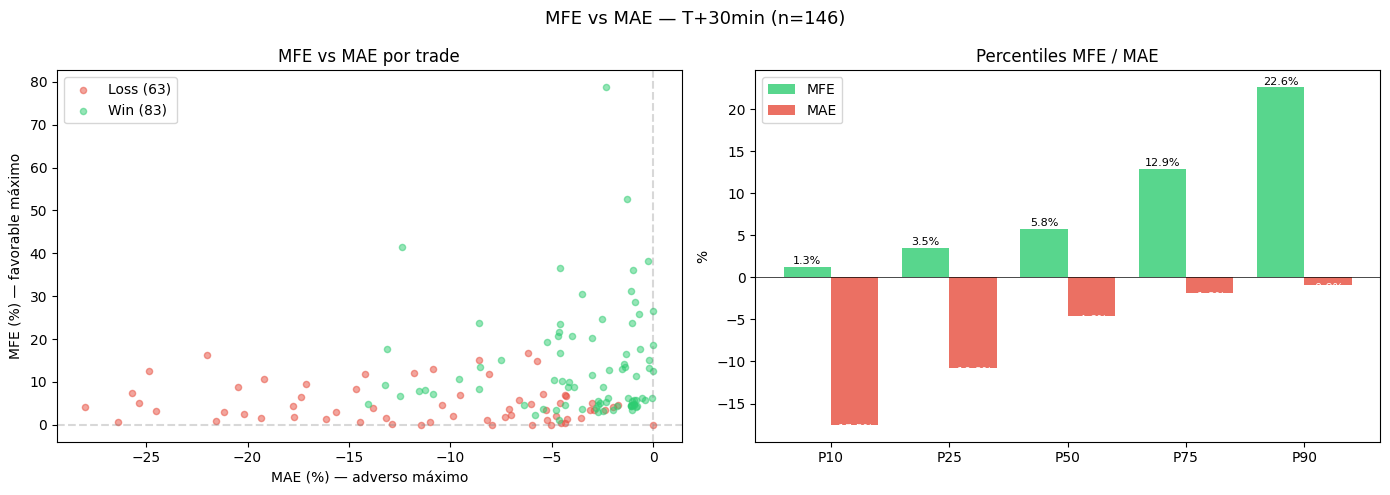

MFE mediana (T+30m): 5.79%
MAE mediana (T+30m): -4.58%
Ratio MFE/|MAE|:      1.45


In [12]:
h = 30
df_mfe = df_valid[[f'ret_{h}m', f'mfe_{h}m', f'mae_{h}m']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'MFE vs MAE — T+{h}min (n={len(df_mfe)})', fontsize=13)

ax = axes[0]
winners = df_mfe[df_mfe[f'ret_{h}m'] > 0]
losers  = df_mfe[df_mfe[f'ret_{h}m'] <= 0]
ax.scatter(losers[f'mae_{h}m']  * 100, losers[f'mfe_{h}m']  * 100, alpha=0.5, color='#e74c3c', s=20, label=f'Loss ({len(losers)})')
ax.scatter(winners[f'mae_{h}m'] * 100, winners[f'mfe_{h}m'] * 100, alpha=0.5, color='#2ecc71', s=20, label=f'Win ({len(winners)})')
ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax.axvline(0, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('MAE (%) — adverso máximo')
ax.set_ylabel('MFE (%) — favorable máximo')
ax.set_title('MFE vs MAE por trade')
ax.legend()

ax = axes[1]
pcts  = [10, 25, 50, 75, 90]
mfe_p = [df_mfe[f'mfe_{h}m'].quantile(p/100) * 100 for p in pcts]
mae_p = [df_mfe[f'mae_{h}m'].quantile(p/100) * 100 for p in pcts]
x = range(len(pcts))
ax.bar([xi - 0.2 for xi in x], mfe_p, width=0.4, color='#2ecc71', alpha=0.8, label='MFE')
ax.bar([xi + 0.2 for xi in x], mae_p, width=0.4, color='#e74c3c', alpha=0.8, label='MAE')
ax.set_xticks(x)
ax.set_xticklabels([f'P{p}' for p in pcts])
ax.set_ylabel('%')
ax.set_title(f'Percentiles MFE / MAE')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)
for xi, (m, a) in enumerate(zip(mfe_p, mae_p)):
    ax.text(xi - 0.2, m + 0.3, f'{m:.1f}%', ha='center', fontsize=8)
    ax.text(xi + 0.2, a - 0.8, f'{a:.1f}%', ha='center', fontsize=8, color='white')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mfe_mae.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'MFE mediana (T+{h}m): {df_mfe[f"mfe_{h}m"].median()*100:.2f}%')
print(f'MAE mediana (T+{h}m): {df_mfe[f"mae_{h}m"].median()*100:.2f}%')
print(f'Ratio MFE/|MAE|:      {(df_mfe[f"mfe_{h}m"] / df_mfe[f"mae_{h}m"].abs()).median():.2f}')

## 11. Enriquecimiento con hype_metrics (Apr 14-17)

¿Filtrando por `rel_volume >= X` o por `signal=confirmed/accelerating` mejora el WR?

In [13]:
hype_lookup = hype_df[['ticker', 'ts', 'date', 'rel_volume', 'delta_5m', 'signal']].copy()

df_apr = df_valid[df_valid['date'] >= '2026-04-14'].copy()
print(f'Eventos en Apr 14-17: {len(df_apr)}')

def _find_hype(ticker, signal_ts, date):
    cands = hype_lookup[(hype_lookup['ticker'] == ticker) & (hype_lookup['date'] == date)]
    if cands.empty:
        return None, None, None
    dt = (cands['ts'] - signal_ts).abs()
    idx = dt.idxmin()
    if dt[idx] > pd.Timedelta('10min'):
        return None, None, None
    r = cands.loc[idx]
    return r['rel_volume'], r['delta_5m'], r['signal']

df_apr[['rv', 'd5m', 'hype_sig']] = [
    _find_hype(r['ticker'], r['ts'], r['date'])
    for _, r in df_apr.iterrows()
]
df_apr_hype = df_apr.dropna(subset=['rv'])
print(f'Con enrichment: {len(df_apr_hype)}')
print()

# Independencia: 1 obs por ticker-day (primera aparición)
def indep_subset(df):
    return df.groupby(['ticker', 'date']).first().reset_index()

print(f'{"Filter":<22} {"n_total":>7} {"n_indep":>7}  {"T+15m WR":>9}  {"T+15m PF":>9}  {"T+30m WR":>9}  {"T+30m PF":>9}')
print('-' * 80)
for label, subset in [
    ('all (Apr 14-17)',   df_apr_hype),
    ('rv >= 5',          df_apr_hype[df_apr_hype['rv'] >= 5]),
    ('rv >= 10',         df_apr_hype[df_apr_hype['rv'] >= 10]),
    ('rv >= 20',         df_apr_hype[df_apr_hype['rv'] >= 20]),
    ('confirmed',        df_apr_hype[df_apr_hype['hype_sig'] == 'confirmed']),
    ('accelerating',     df_apr_hype[df_apr_hype['hype_sig'] == 'accelerating']),
]:
    sub_indep = indep_subset(subset)
    stats = []
    for h in [15, 30]:
        s = sub_indep[f'ret_net_{h}m'].dropna()
        if len(s) < 3:
            stats += [f'n={len(s)}', '-']
            continue
        wr = (s > 0).mean()
        pf = s[s > 0].sum() / abs(s[s < 0].sum()) if (s < 0).any() else 9.99
        stats += [f'{wr:.1%}', f'{pf:.2f}x']
    n_total = len(subset['ret_net_15m'].dropna())
    n_indep = len(sub_indep['ret_net_15m'].dropna())
    print(f'{label:<22} {n_total:>7} {n_indep:>7}  {stats[0]:>9}  {stats[1]:>9}  {stats[2]:>9}  {stats[3]:>9}')

print()
print('NOTA: n_indep = ticker-days únicos. Cualquier grupo con n_indep < 5 no es concluyente.')
print('      El PF alto en "confirmed" era XNDU x9 snapshots un solo día → n_indep=1.')


Eventos en Apr 14-17: 54
Con enrichment: 50

Filter                 n_total n_indep   T+15m WR   T+15m PF   T+30m WR   T+30m PF
--------------------------------------------------------------------------------
all (Apr 14-17)             50       2        n=2          -        n=2          -
rv >= 5                     43       2        n=2          -        n=2          -
rv >= 10                    36       2        n=2          -        n=2          -
rv >= 20                    19       1        n=1          -        n=1          -
confirmed                    9       1        n=1          -        n=1          -
accelerating                 0       0        n=0          -        n=0          -

NOTA: n_indep = ticker-days únicos. Cualquier grupo con n_indep < 5 no es concluyente.
      El PF alto en "confirmed" era XNDU x9 snapshots un solo día → n_indep=1.


## 12. Resumen ejecutivo

In [14]:
print('=' * 65)
print('RESUMEN EJECUTIVO — Reactive Signal Edge')
print('=' * 65)
print(f'Universo : Top Gainers >= {MIN_CHG_PCT}% | {len(df_valid)} eventos con barras')
print(f'Período  : {df_valid["date"].min()} → {df_valid["date"].max()}')
print(f'Datos    : {df_valid["date"].nunique()} días | {df_valid["ticker"].nunique()} tickers')
print()
print('--- Independiente + slippage ---')
print(summary_indep.to_string(index=False, float_format='{:.3f}'.format))
print()
print(f'--- Exploratorio (todos, sin slippage, n={len(df_valid)}) ---')
print(edge_summary(df_valid, HORIZONS).to_string(index=False, float_format='{:.3f}'.format))
print()
print('--- Mejor sesión (T+15m) ---')
for sess in ['9:30-10:00', '10:00-11:00', '11:00-13:00', '13:00-15:00', '15:00-16:00']:
    s = df_valid[df_valid['session'] == sess]['ret_15m'].dropna()
    if len(s) < 3:
        continue
    wr = (s > 0).mean()
    pf = s[s > 0].sum() / abs(s[s < 0].sum()) if (s < 0).any() else 9.99
    print(f'  {sess:15s}: WR={wr:.1%}  PF={pf:.2f}x  n={len(s)}')
print()
print('NOTA: ~15 días de datos. Resultados son hipótesis iniciales.')
print('Si hay señal clara → ampliar burst_intraday_cache con backfill.')

RESUMEN EJECUTIVO — Reactive Signal Edge
Universo : Top Gainers >= 15.0% | 146 eventos con barras
Período  : 2026-03-25 → 2026-04-16
Datos    : 8 días | 14 tickers

--- Independiente + slippage ---
horizonte  n    wr  profit_factor  avg_ret_pct  avg_win_pct  avg_loss_pct  median_ret_pct
    T+15m 14 0.286          0.631       -1.243        7.425        -4.710          -3.091
    T+30m 14 0.429          0.732       -1.187        7.563        -7.749          -1.682
    T+60m 14 0.429          1.072        0.482       16.660       -11.651          -0.603
   T+120m 14 0.429          0.961       -0.300       17.477       -13.633          -1.614

--- Exploratorio (todos, sin slippage, n=146) ---
horizonte   n    wr  profit_factor  avg_ret_pct  avg_win_pct  avg_loss_pct  median_ret_pct
    T+15m 146 0.568          1.326        0.831        5.944        -6.100           0.707
    T+30m 146 0.568          1.576        1.666        8.016        -6.809           1.034
    T+60m 146 0.623         